##**AirQuality_Index_PredictionModel**

In [ ]:
# import Data Manipulation libraries
import numpy as np
import pandas as pd

# import Data Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# import loggings
import logging
logging.basicConfig(level = logging.INFO,
                    filename = 'model.log',
                    filemode = 'w',
                    format = '%(asctime)s:%(levelname)s:%(message)s',
                    force = True)

import warnings
warnings.filterwarnings(action = 'ignore')

from sklearn.preprocessing import MinMaxScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.metrics import r2_score



##**Data Ingestion**

In [ ]:
import pandas as pd

df = pd.read_excel('/content/AirQualityUCI.xlsx')
df.sample(frac = 1)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
4141,2004-08-30,07:00:00,-200.0,1335.75,-200,23.275935,1384.75,-200.0,477.25,-200.0,2133.25,1357.25,22.550000,60.349999,1.628725
4656,2004-09-20,18:00:00,5.6,1425.50,-200,31.134429,1577.25,566.0,521.00,200.0,2080.00,1647.75,30.525001,29.250000,1.258460
3091,2004-07-17,13:00:00,1.4,1002.50,-200,8.178485,906.50,76.0,862.25,91.0,1427.00,680.25,39.324999,13.875000,0.971491
5526,2004-10-27,00:00:00,2.0,1134.75,-200,9.228796,948.25,215.0,684.50,80.0,1568.50,992.00,17.600000,80.525002,1.606176
4746,2004-09-24,12:00:00,3.7,1375.50,-200,22.299186,1359.00,422.0,530.00,143.0,1997.75,1435.25,26.225000,45.950001,1.542170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,2004-08-10,01:00:00,0.7,941.75,-200,4.897490,758.25,17.0,824.25,29.0,1567.25,856.00,28.075000,51.550000,1.926908
6590,2004-12-10,08:00:00,1.4,919.25,-200,5.649154,795.25,315.0,2327.00,110.0,997.50,821.75,12.250000,35.775000,0.508626
230,2004-03-20,08:00:00,2.1,1299.75,-200,8.883264,934.75,170.0,902.25,113.0,1623.00,1144.75,13.750000,58.025001,0.908270
4924,2004-10-01,22:00:00,-200.0,1213.50,-200,11.214592,1022.00,-200.0,645.00,-200.0,1592.00,1235.25,21.325000,63.025000,1.579789


[]

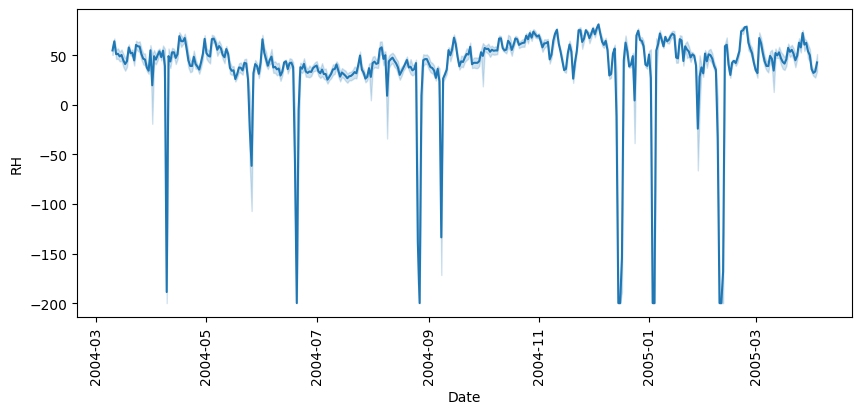

In [ ]:
plt.figure(figsize = (10,4))
sns.lineplot(data = df,x = 'Date',y = 'RH')
plt.xticks(rotation = 90)
plt.plot()

In [ ]:
# Dropping Unwanted Columns
df.drop(columns = ['Date', 'Time'],inplace = True)

In [ ]:
# Descrptive Stats : Numerical Columns
df

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,3.1,1314.25,-200,13.529605,1101.25,471.7,538.50,189.8,1374.25,1728.50,21.850,29.250000,0.756824
9353,2.4,1162.50,-200,11.355157,1027.00,353.3,603.75,179.2,1263.50,1269.00,24.325,23.725000,0.711864
9354,2.4,1142.00,-200,12.374538,1062.50,293.0,603.25,174.7,1240.75,1092.00,26.900,18.350000,0.640649
9355,2.1,1002.50,-200,9.547187,960.50,234.5,701.50,155.7,1041.00,769.75,28.325,13.550000,0.513866


##**Descriptive statistics**

In [ ]:
# if the skewness is gteater than +3 or -3 then there is a Outliers.

# Descriptive statistics


# Checking Outliers Present in Dataset: Age column
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
Outliers = df[((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis = 1)]
print('numeber of Outliers:',len(Outliers))

from collections import OrderedDict

stats = []

for i in df.select_dtypes(exclude = 'object').columns:
  numerical_stats = OrderedDict({
      'Feature': i,
      'missing_value %': df[i].isnull().sum() / len(df) * 100,
      'unique_value': df[i].nunique(),
      'count': df[i].count(),
      'min': df[i].min(),
      'max': df[i].max(),
      'Mean': df[i].mean(),
      'Median': df[i].median(),
      'Q1': df[i].quantile(0.25),
      'Q2': df[i].quantile(0.50),
      'Q3': df[i].quantile(0.75),
      'Std': df[i].std(),
      'Skewness': df[i].skew(),
      'Kurtosis': df[i].kurtosis(),
      'Outliers': len(Outliers)
  })
  stats.append(numerical_stats)

report = pd.DataFrame(stats)

report

numeber of Outliers: 3894


,Feature,missing_value %,unique_value,count,min,max,Mean,Median,Q1,Q2,Q3,Std,Skewness,Kurtosis,Outliers
0,CO(GT),0.0,97,9357,-200.0,11.900000,-34.207524,1.500000,0.600000,1.500000,2.600000,77.657170,-1.666180,0.778306,3894
1,PT08.S1(CO),0.0,3246,9357,-200.0,2039.750000,1048.869652,1052.500000,921.000000,1052.500000,1221.250000,329.817015,-1.721126,5.835512,3894
2,NMHC(GT),0.0,430,9357,-200.0,1189.000000,-159.090093,-200.000000,-200.000000,-200.000000,-200.000000,139.789093,4.075784,18.863824,3894
3,C6H6(GT),0.0,3773,9357,-200.0,63.741476,1.865576,7.886653,4.004958,7.886653,13.636091,41.380154,-4.508775,19.188714,3894
4,PT08.S2(NMHC),0.0,3773,9357,-200.0,2214.000000,894.475963,894.500000,711.000000,894.500000,1104.750000,342.315902,-0.793153,2.369425,3894
5,NOx(GT),0.0,2467,9357,-200.0,1479.000000,168.604200,141.000000,50.000000,141.000000,284.200000,257.424561,0.825255,1.505566,3894
6,PT08.S3(NOx),0.0,3519,9357,-200.0,2682.750000,794.872333,794.250000,637.000000,794.250000,960.250000,321.977031,-0.384464,3.104215,3894
7,NO2(GT),0.0,1420,9357,-200.0,339.700000,58.135898,96.000000,53.000000,96.000000,133.000000,126.931428,-1.225789,0.275717,3894
8,PT08.S4(NO2),0.0,4408,9357,-200.0,2775.000000,1391.363266,1445.500000,1184.750000,1445.500000,1662.000000,467.192382,-1.243944,3.266388,3894
9,PT08.S5(O3),0.0,4679,9357,-200.0,2522.750000,974.951534,942.000000,699.750000,942.000000,1255.250000,456.922728,-0.034500,0.637957,3894


##**HeatMap Showing the Feature Selection**

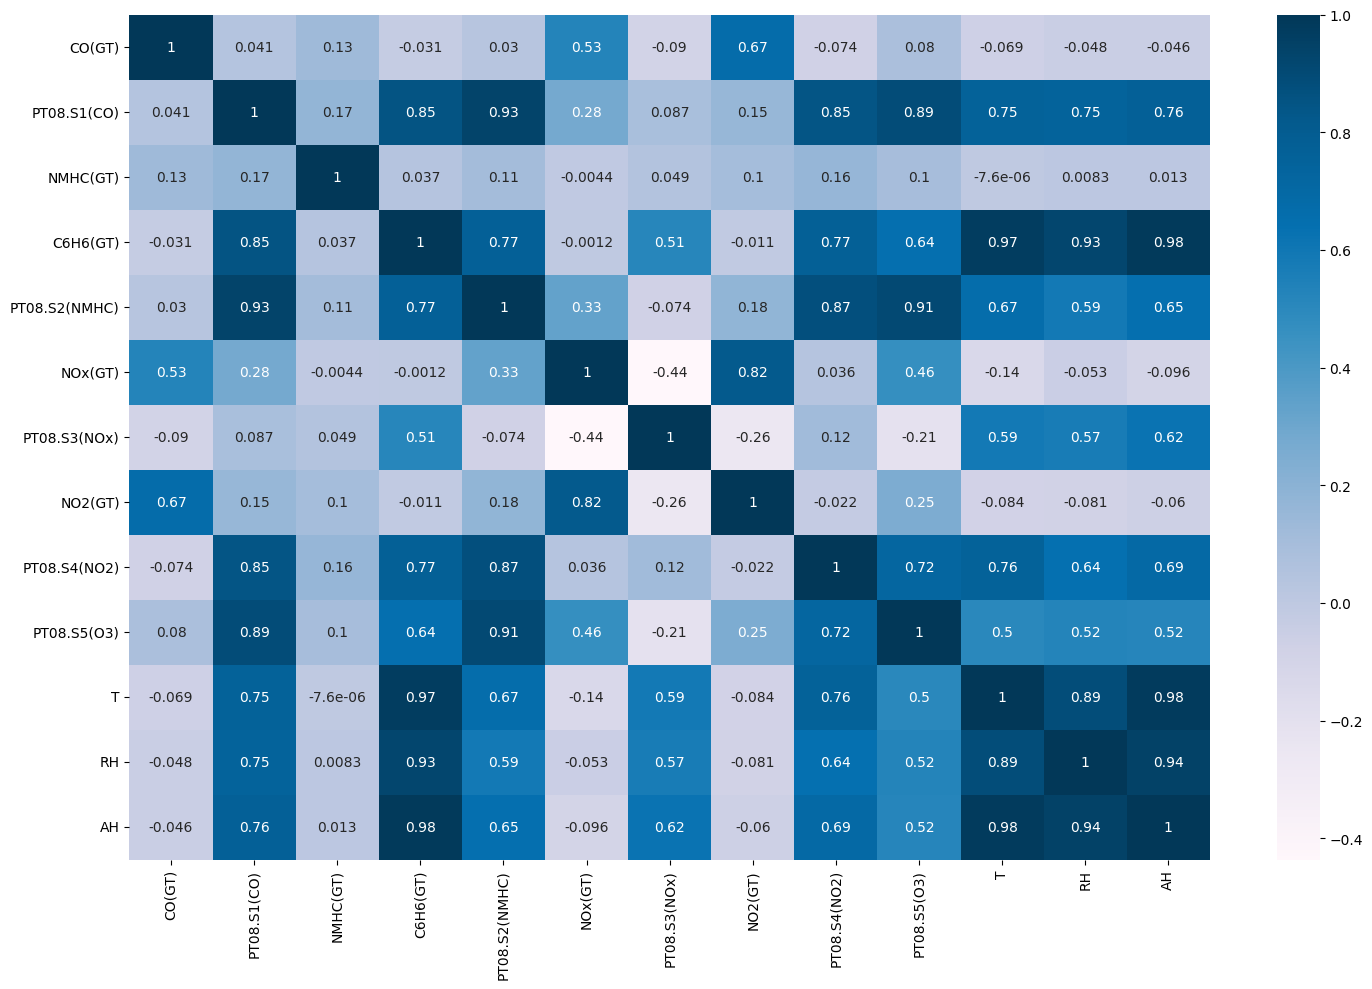

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(),annot = True,cmap = 'PuBu',)
plt.tight_layout()
plt.show()

##**Showing Correlation with Target Column**

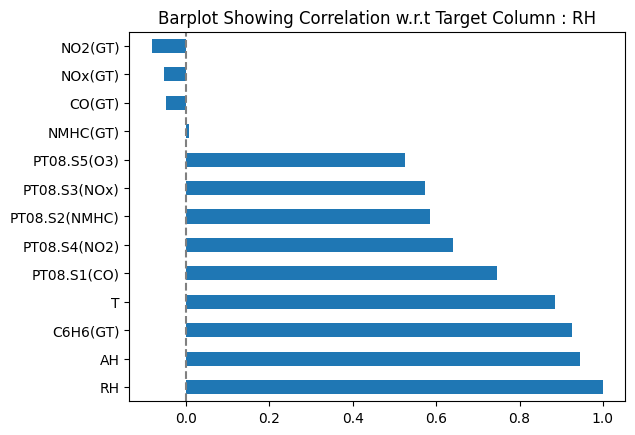

In [ ]:
df.corr()['RH'].sort_values(ascending= False).plot(kind = 'barh')
plt.title('Barplot Showing Correlation w.r.t Target Column : RH')
plt.axvline(0,color = 'gray',linestyle = '--')
plt.show()

##**Winsorization Method for capping the Outliers***

In [ ]:
# Using Winsorization Technique to Capp the Outliers with LowerBound and UpperBound
'''
Obervation:
- Data contains outliers in maximum columns
- Data is Skewed and contains outliers which makes machine model overfit.
- So Hence, We use Winsorization Technique to Capp the Outliers with LowerBound and UpperBound.

'''
from scipy.stats.mstats import winsorize

for i in df.select_dtypes(exclude = 'object').columns:
  df[i] = winsorize(df[i],limits = [0.05,0.05])  #(lower_limit,upper_limit)


df['RH'].max(),df['RH'].median(),df['RH'].min()



(77.625001907349, 48.550000190735, 15.025000095367)

Descriptive statistics

In [ ]:
from collections import OrderedDict

stats = []

for i in df.select_dtypes(exclude = 'object').columns:
  numerical_stats = OrderedDict({
      'Feature': i,
      'missing_value %': df[i].isnull().sum() / len(df) * 100,
      'unique_value': df[i].nunique(),
      'count': df[i].count(),
      'min': df[i].min(),
      'max': df[i].max(),
      'Mean': df[i].mean(),
      'Median': df[i].median(),
      'Q1': df[i].quantile(0.25),
      'Q2': df[i].quantile(0.50),
      'Q3': df[i].quantile(0.75),
      'Std': df[i].std(),
      'Skewness': df[i].skew(),
      'Kurtosis': df[i].kurtosis()
  })
  stats.append(numerical_stats)

report = pd.DataFrame(stats)

report

,Feature,missing_value %,unique_value,count,min,max,Mean,Median,Q1,Q2,Q3,Std,Skewness,Kurtosis
0,CO(GT),0.0,48,9357,-200.000000,4.700000,-34.267960,1.500000,0.600000,1.500000,2.600000,77.625954,-1.666477,0.778763
1,PT08.S1(CO),0.0,2760,9357,745.500000,1501.750000,1080.352864,1052.500000,921.000000,1052.500000,1221.250000,208.814272,0.401767,-0.691228
2,NMHC(GT),0.0,132,9357,-200.000000,145.000000,-169.805066,-200.000000,-200.000000,-200.000000,-200.000000,92.809402,2.813060,6.100387
3,C6H6(GT),0.0,3299,9357,0.734469,24.455875,9.431888,7.886653,4.004958,7.886653,13.636091,6.685558,0.742452,-0.392317
4,PT08.S2(NMHC),0.0,3299,9357,470.750000,1415.250000,914.245912,894.500000,711.000000,894.500000,1104.750000,260.501378,0.216756,-0.813951
5,NOx(GT),0.0,2094,9357,-200.000000,654.000000,159.277984,141.000000,50.000000,141.000000,284.200000,232.454662,0.250642,-0.283511
6,PT08.S3(NOx),0.0,3014,9357,409.750000,1281.500000,807.971403,794.250000,637.000000,794.250000,960.250000,233.669120,0.262768,-0.623171
7,NO2(GT),0.0,1119,9357,-200.000000,194.000000,56.658331,96.000000,53.000000,96.000000,133.000000,125.019007,-1.308536,0.307251
8,PT08.S4(NO2),0.0,3916,9357,756.500000,2020.500000,1419.758657,1445.500000,1184.750000,1445.500000,1662.000000,343.634016,-0.181318,-0.709050
9,PT08.S5(O3),0.0,4187,9357,347.750000,1750.250000,986.543639,942.000000,699.750000,942.000000,1255.250000,387.293638,0.300954,-0.740690


##**Split the dataset into X & Y**

In [ ]:
# Step1 : split the dataset into X and Y

X = df.drop(columns = ['RH'],axis = 1)
Y = df['RH']

# step 2 : use train and test split

X_train,X_test,y_train,y_test = train_test_split(X,Y,
                                                 test_size = 0.2,
                                                 random_state = 1)

# Step 3 :

sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Model Building**

In [ ]:
# Model Building
# from sklearn.ensemble import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor as DecisionTreesRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    'RandomForestRegressor': RandomForestRegressor(),
    'ExtraTreesRegressor': ExtraTreesRegressor(),
    'DecisionTreeRegressor': DecisionTreesRegressor(),
    'KNeighborsRegressor': KNeighborsRegressor()
}

for model_name, model in models.items():

  model.fit(X_train,y_train)   # Seen Data
  y_pred = model.predict(X_test)  # Unseen Data
  print(r2_score(y_test,y_pred))

0.9961611377516065
0.9961456817237863
0.99066315879905
0.9342300391844552


##**Elbow Method**

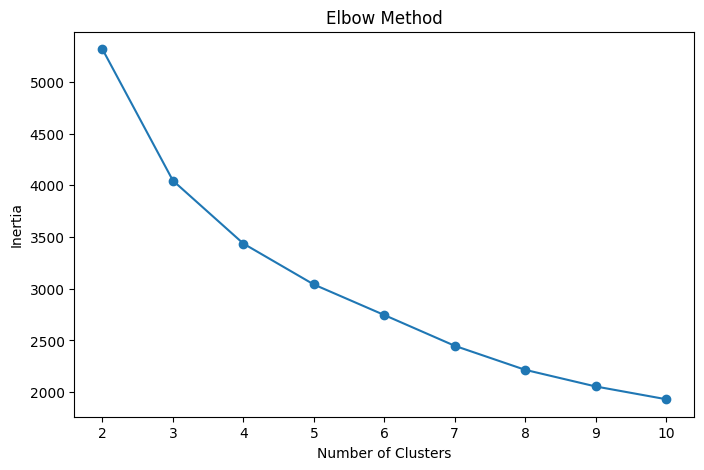

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_train)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


##**KNeighborsRegressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(r2_score(y_test,y_pred))

0.9342300391844552


##**Distribution of Residuals**

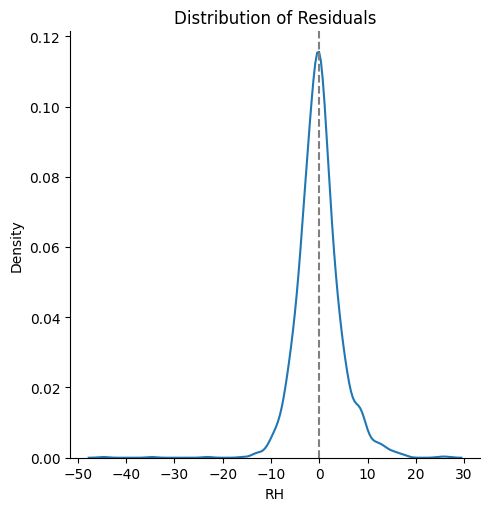

In [ ]:
sns.displot(y_test-y_pred,kind = 'kde')
plt.axvline(0,color = 'gray',linestyle = '--')
plt.title('Distribution of Residuals')
plt.show()

##**Actual & Predicted Values**

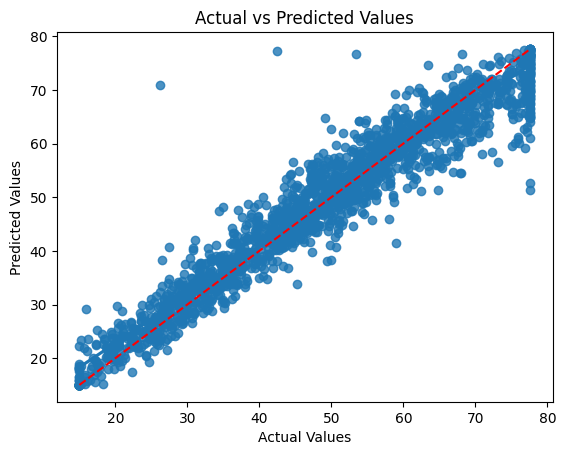

In [ ]:
sns.regplot(x = y_test,y = y_pred)
sns.lineplot(x = y_test,y = y_test,color = 'red',linestyle = '--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()